In [1]:
SAVE_DIR = "."
try:
    from google.colab import drive
    drive.mount('/content/drive')
    SAVE_DIR = "/content/drive/MyDrive"
    print("Drive mounted. Plots will be saved to:", SAVE_DIR)
except Exception as e:
    print("Not on Colab (or skipped). Saving locally. Reason:", type(e).__name__)

Mounted at /content/drive
Drive mounted. Plots will be saved to: /content/drive/MyDrive


# Group 1 · Lab B — MLP vs CNN on MNIST (and the overfitting gap)

**What this lab proves (Card 4 made real):**

1. A **fully-connected net (MLP)** treats an image as a flat list of pixels. It works, but it needs a *huge* number of parameters and ignores spatial structure.
2. A **CNN** uses convolution + pooling. It gets **higher accuracy with FAR fewer parameters** — the whole point of Card 4.
3. By tracking **train vs test accuracy** each epoch, we expose **overfitting** — the train/test gap. That's the second problem Group 1 hands to Group 2.

*All PyTorch, hand-written training loop (no `.fit()`), so every step stays visible.*

In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 2 · Load MNIST

MNIST = 70,000 grayscale 28×28 images of handwritten digits 0–9 (60k train, 10k test). `transforms.ToTensor()` converts each image to a tensor and scales pixels from [0,255] to [0,1] — networks train better on small, normalized inputs.

A **DataLoader** serves the data in shuffled mini-batches. We train on batches (not one image at a time, not all 60k at once) because it's the right balance of speed and stable gradient estimates.

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.09MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 135kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.19MB/s]


Train images: 60000,  Test images: 10000


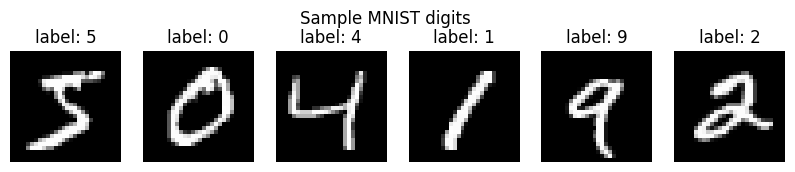

In [3]:
transform = transforms.ToTensor()

train_set = torchvision.datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_set  = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)   # shuffle: different order each epoch
test_loader  = DataLoader(test_set,  batch_size=64, shuffle=False)  # no need to shuffle for evaluation

print(f"Train images: {len(train_set)},  Test images: {len(test_set)}")

# Peek at a few digits.
fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for ax, i in zip(axes, range(6)):
    img, label = train_set[i]
    ax.imshow(img.squeeze(), cmap="gray"); ax.set_title(f"label: {label}"); ax.axis("off")
plt.suptitle("Sample MNIST digits"); plt.show()


## 3 · Model 1 — the MLP (fully-connected)

This is the **Card 4 baseline: the "wrong" way for images.** `nn.Flatten()` turns each 28×28 image into a 784-long vector — which **throws away all spatial information** (which pixels were neighbours). Then fully-connected layers map 784 → 256 → 128 → 10.

Watch the parameter count in section 5: connecting every pixel to every neuron is expensive.

In [4]:
# "class" defines a blueprint for an object. MLP is our model's type.
# "(nn.Module)" means MLP INHERITS from PyTorch's base class nn.Module —
# it gets all of PyTorch's model machinery (parameter tracking, .to(device),
# .train()/.eval(), etc.) for free. Every model you build subclasses nn.Module.
class MLP(nn.Module):

    # __init__ is the CONSTRUCTOR. It runs ONCE, at the moment you create the
    # model with `model = MLP()`. Its job is to build and store the layers.
    # "self" = the specific object being created. It's how each instance refers
    # to its OWN data. Every method's first parameter is self; Python passes it
    # automatically, so you write MLP(), not MLP(self). Think of self as "this
    # particular model." Anything saved as self.<name> lives on the object and
    # is available later in other methods.
    def __init__(self):

        # super().__init__() calls nn.Module's OWN constructor first. This is
        # REQUIRED — it sets up the internal bookkeeping (like the registry that
        # tracks your layers' weights). Skip it and PyTorch won't see your
        # parameters. Always the first line of __init__ in a model.
        super().__init__()

        # We store the network on the object as self.net, so forward() can use
        # it later. nn.Sequential chains layers: the output of each feeds the next.
        self.net = nn.Sequential(
            nn.Flatten(),                 # 28x28 image -> 784 vector (spatial info lost here)
            nn.Linear(28*28, 256), nn.ReLU(),  # fully-connected 784->256, then activation
            nn.Linear(256, 128),   nn.ReLU(),  # 256->128, then activation
            nn.Linear(128, 10),           # 10 outputs = scores for digits 0-9
        )

    # forward() defines WHAT THE MODEL DOES to an input. It runs EVERY time you
    # pass data through the model. "x" is the input batch of images.
    # You do NOT call this directly. When you write `model(x)`, PyTorch's
    # nn.Module internally calls forward(x) for you (plus extra setup around it).
    # That's why we write model(x), never model.forward(x).
    def forward(self, x):
        return self.net(x)   # push x through the stored layers, return the output

## 4 · Model 2 — the CNN (convolution + pooling)

This is **Card 4's fix.** Instead of flattening, we slide small 3×3 filters across the image (`Conv2d`), preserving spatial structure and reusing the same weights everywhere (**weight sharing**). `MaxPool2d(2)` halves the spatial size each time, keeping the strongest responses.

- Input 1×28×28 → conv→16 channels → pool → 16×14×14 → conv→32 channels → pool → 32×7×7
- Then flatten the 32×7×7 features and a single Linear layer maps to 10 classes.

The convolutional layers have **very few parameters** (a filter is just 3×3 = 9 weights, reused), which is why the CNN is so much smaller than the MLP.

In [5]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Feature extractor: two (conv -> ReLU -> pool) blocks.
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(),  # 1 -> 16 channels, keeps 28x28
            nn.MaxPool2d(2),                                        # 28x28 -> 14x14
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), # 16 -> 32 channels, keeps 14x14
            nn.MaxPool2d(2),                                        # 14x14 -> 7x7
        )
        # Classifier head: flatten the 32x7x7 feature maps -> 10 class scores.
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32*7*7, 10),
        )
    def forward(self, x):
        x = self.features(x)      # learn spatial features
        return self.classifier(x) # turn them into class scores


## 5 · Parameter count — the first half of Card 4's claim

Before training, just *count the parameters*. This alone shows the MLP is far heavier than the CNN, even though the CNN is about to score higher. Fewer parameters + better accuracy = the CNN is a fundamentally better *fit* for image data.

In [6]:
# A small helper function to count how many learnable numbers a model has.
# "model.parameters()" is given to us by nn.Module — it returns every weight
# and bias tensor in the model (all the things training will adjust).
def count_params(model):
    # For each parameter tensor p, p.numel() = "number of elements" in it
    # (e.g. a 256x784 weight matrix has 256*784 = 200,704 elements).
    # sum(...) adds those counts across every layer = total parameters.
    # The "(p.numel() for p in ...)" part is a generator: it loops over every
    # parameter tensor and yields its element count, one at a time, to sum().
    return sum(p.numel() for p in model.parameters())

# Create one instance of each model (this runs each class's __init__ once).
# ".to(device)" moves the model's parameters onto the GPU (or CPU) so it
# computes on the same device as the data. It returns the model, so we can
# chain it right after MLP()/CNN().
mlp = MLP().to(device)
cnn = CNN().to(device)

# f"..." is an f-string: anything inside {curly braces} is evaluated and
# inserted into the text. The ":," after the value is a format spec meaning
# "print this number with thousands separators" -> 235,146 instead of 235146.
print(f"MLP parameters: {count_params(mlp):,}")
print(f"CNN parameters: {count_params(cnn):,}")

# "\n" is a newline (blank line before this print, for spacing).
# The ":.1f" format spec means "show as a float with 1 digit after the decimal"
# -> 11.5 instead of 11.4732... . Here we divide the two counts to get the ratio.
print(f"\nThe MLP has ~{count_params(mlp)/count_params(cnn):.1f}x MORE parameters than the CNN.")

# A plain string, no formatting needed — just the takeaway message.
print("Yet the CNN will score higher — because it respects image structure (Card 4).")

MLP parameters: 235,146
CNN parameters: 20,490

The MLP has ~11.5x MORE parameters than the CNN.
Yet the CNN will score higher — because it respects image structure (Card 4).


## 6 · One hand-written train/eval engine for both models

Same four-stage loop as Lab A (forward → loss → backward → update), now wrapped in a function so we can run it for both models fairly. We also compute **accuracy**, and crucially we run an evaluation pass on the **test set** each epoch so we can watch the train/test gap.

`CrossEntropyLoss` is the right loss for multi-class classification (Card 2). In PyTorch it expects raw scores (logits) — it applies the softmax internally — which is why neither model has a softmax layer at the end.

In [7]:
# criterion = the loss function object. We create it once and reuse it every batch.
# CrossEntropyLoss is the standard loss for multi-class classification (Card 2).
criterion = nn.CrossEntropyLoss()

# ONE function that handles BOTH training and evaluation. The trick: whether we
# pass an optimizer decides the mode. optimizer=None is the DEFAULT, so calling
# run_epoch(model, loader) with no optimizer = evaluation; passing one = training.
def run_epoch(model, loader, optimizer=None):
    """One pass over `loader`. If `optimizer` is given -> training; else -> evaluation."""

    # "is optimizer None?" -> if we were given an optimizer, we're training.
    # This boolean is used a few times below to switch behaviour.
    is_train = optimizer is not None

    # Put the model in the right MODE. This is a one-line if/else expression:
    #   (do this) if (condition) else (do that)
    # model.train() and model.eval() flip internal switches — they matter for
    # layers like Dropout/BatchNorm that behave differently in train vs eval.
    # (Our current models don't use those yet, but this is correct habit.)
    model.train() if is_train else model.eval()

    # Running tallies for the whole epoch. We start them at zero and add to them
    # batch by batch. Python lets you assign several at once on one line.
    total, correct, loss_sum = 0, 0, 0.0

    # "with torch.set_grad_enabled(...)" is a CONTEXT MANAGER: everything indented
    # under it runs with gradient tracking turned ON (training) or OFF (eval).
    # Turning it off during eval makes it faster and use less memory, because
    # PyTorch doesn't build the graph needed for backprop.
    with torch.set_grad_enabled(is_train):

        # Loop over the DataLoader. Each iteration hands us one mini-batch:
        # X = a batch of images, y = their true labels. The DataLoader slices the
        # dataset into batches for us (batch_size=64), so this loop runs
        # (dataset size / 64) times per epoch.
        for X, y in loader:

            # Move this batch onto the same device as the model (GPU/CPU).
            X, y = X.to(device), y.to(device)

            logits = model(X)              # 1) FORWARD: raw class scores (no softmax)
            loss = criterion(logits, y)    # 2) LOSS: compare scores to true labels

            # Only update weights when training. In eval we skip this entirely —
            # we're just measuring, not learning.
            if is_train:
                optimizer.zero_grad()      # clear old grads (PyTorch accumulates)
                loss.backward()            # 3) BACKPROP: fill each param's .grad
                optimizer.step()           # 4) UPDATE: optimizer nudges weights

            # --- accumulate stats for reporting ---

            # loss.item() pulls the loss out as a plain Python number.
            # We multiply by X.size(0) (= this batch's size, usually 64) because
            # criterion already AVERAGED over the batch; multiplying back gives the
            # batch TOTAL, so batches of different sizes are weighted fairly.
            loss_sum += loss.item() * X.size(0)

            # logits.argmax(1) = index of the highest score per image = the
            # predicted digit. "== y" compares to the truth (True/False per image).
            # .sum() counts the Trues; .item() makes it a Python int.
            correct  += (logits.argmax(1) == y).sum().item()

            # X.size(0) = number of images in this batch. Summed over all batches
            # this becomes the total number of images seen this epoch.
            total    += X.size(0)

    # Return average loss (total loss / #images) and accuracy (#correct / #images).
    return loss_sum / total, correct / total

## 7 · Train both models and record everything

We train each model for a few epochs with the Adam optimizer, recording train and test accuracy every epoch so we can plot learning curves and the overfitting gap afterward.

In [8]:
# train_model runs the full training for ONE model over several epochs.
# Parameters have DEFAULTS: epochs=5 and lr=1e-3 (0.001). If you call
# train_model(mlp) they're used as-is; you can override like train_model(mlp, 20).
def train_model(model, epochs=5, lr=1e-3):

    # The OPTIMIZER implements the weight-update rule (Group 2 topic). Adam is a
    # smart default. We hand it model.parameters() so it knows which tensors to
    # update, and lr = the learning rate (step size). This is the same idea as
    # Lab A's manual "p -= lr * p.grad", just automated and smarter.
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # A dictionary to record accuracy after each epoch. Two keys, each holding a
    # list we'll append to. We use this afterward to plot the curves.
    history = {"train_acc": [], "test_acc": []}

    # One loop iteration = one epoch = one full pass over the training data.
    # range(epochs) gives 0,1,2,... so ep counts the epochs.
    for ep in range(epochs):

        # TRAIN pass: we PASS the optimizer, so run_epoch trains (updates weights).
        # It returns (avg_loss, accuracy); we unpack both, keep the accuracy.
        tr_loss, tr_acc = run_epoch(model, train_loader, optimizer)  # train

        # EVAL pass: NO optimizer passed, so run_epoch only measures — no weight
        # updates, no learning. This tells us how the model does on unseen data.
        te_loss, te_acc = run_epoch(model, test_loader)              # evaluate

        # Save this epoch's two accuracies into the history lists.
        history["train_acc"].append(tr_acc)
        history["test_acc"].append(te_acc)

        # Print a progress line. Format specs: :.4f = 4 decimals; :+.4f = 4
        # decimals WITH a forced +/- sign, so the gap shows its direction.
        # The gap (train - test) is our overfitting signal: bigger = more overfit.
        print(f"  epoch {ep+1}: train_acc {tr_acc:.4f} | test_acc {te_acc:.4f} | gap {tr_acc-te_acc:+.4f}")

    # Hand back the full record so we can plot it later.
    return history


EPOCHS = 5   # a shared setting so both models train for the same length (fair test)

# --- Train the MLP ---
print("Training MLP:")
mlp = MLP().to(device)                 # fresh model (new random weights)
mlp_hist = train_model(mlp, EPOCHS)    # train it, keep its history

# --- Train the CNN ---
print("\nTraining CNN:")               # \n = blank line before this, for spacing
cnn = CNN().to(device)                 # fresh model
cnn_hist = train_model(cnn, EPOCHS)    # train it, keep its history

Training MLP:
  epoch 1: train_acc 0.9176 | test_acc 0.9601 | gap -0.0425
  epoch 2: train_acc 0.9686 | test_acc 0.9723 | gap -0.0037
  epoch 3: train_acc 0.9786 | test_acc 0.9754 | gap +0.0032
  epoch 4: train_acc 0.9837 | test_acc 0.9767 | gap +0.0070
  epoch 5: train_acc 0.9873 | test_acc 0.9800 | gap +0.0073

Training CNN:
  epoch 1: train_acc 0.9290 | test_acc 0.9759 | gap -0.0469
  epoch 2: train_acc 0.9785 | test_acc 0.9818 | gap -0.0033
  epoch 3: train_acc 0.9836 | test_acc 0.9843 | gap -0.0007
  epoch 4: train_acc 0.9864 | test_acc 0.9864 | gap -0.0000
  epoch 5: train_acc 0.9884 | test_acc 0.9853 | gap +0.0031


## 8 · Result 1 — CNN beats MLP on accuracy

The second half of Card 4's claim. Despite having ~10× fewer parameters, the CNN should reach higher test accuracy. Fewer parameters *and* better results is the definition of a better architectural fit.

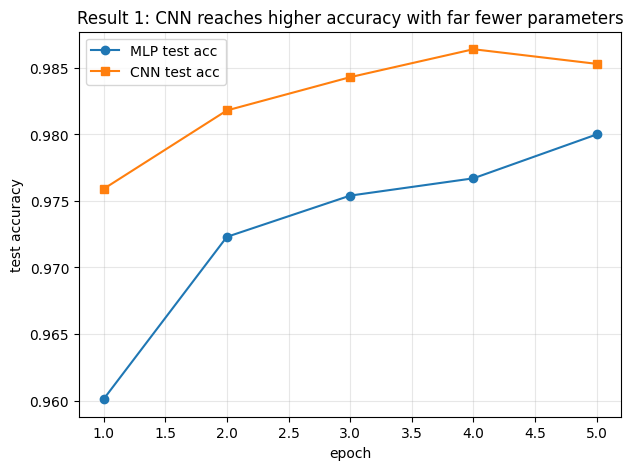

Final MLP test acc: 0.9800  (235,146 params)
Final CNN test acc: 0.9853  (20,490 params)


In [9]:
plt.figure(figsize=(7, 5))
epochs_range = range(1, EPOCHS+1)
plt.plot(epochs_range, mlp_hist["test_acc"], 'o-', label="MLP test acc")
plt.plot(epochs_range, cnn_hist["test_acc"], 's-', label="CNN test acc")
plt.xlabel("epoch"); plt.ylabel("test accuracy"); plt.legend()
plt.title("Result 1: CNN reaches higher accuracy with far fewer parameters")
plt.grid(True, alpha=0.3)
plt.savefig(f"{SAVE_DIR}/lab_b_accuracy.png", dpi=120)
plt.show()

print(f"Final MLP test acc: {mlp_hist['test_acc'][-1]:.4f}  ({count_params(mlp):,} params)")
print(f"Final CNN test acc: {cnn_hist['test_acc'][-1]:.4f}  ({count_params(cnn):,} params)")


## 9 · Result 2 — expose overfitting (the train/test gap)

**Overfitting** = the model does better on data it has seen (train) than on data it hasn't (test). On the plot, it's the **gap** between the train curve and the test curve: the model is memorizing training specifics that don't generalize.

This is the second problem Group 1 leaves open. Group 2's regularization tools — **dropout, L2 weight decay, data augmentation** — exist to *shrink this gap*. Watching it appear here is what makes those tools feel necessary.

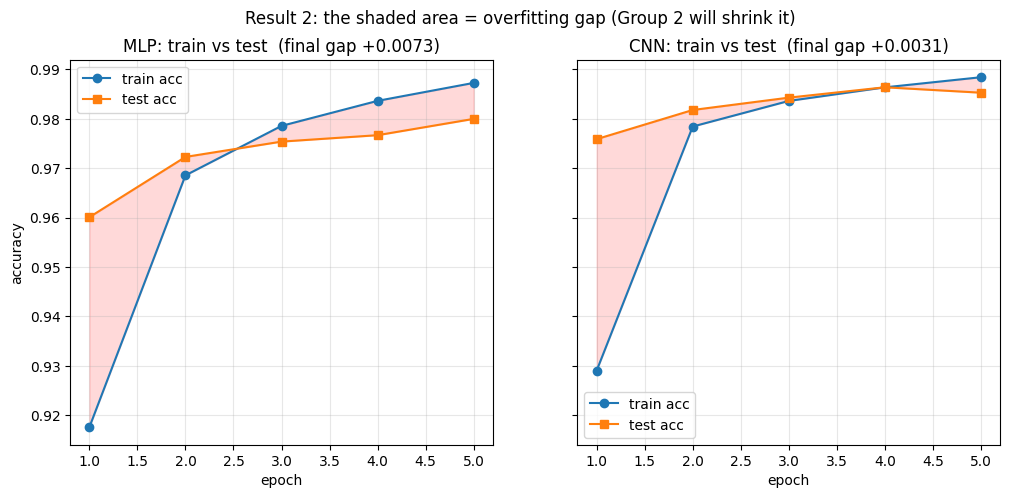

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, hist, name in [(axes[0], mlp_hist, "MLP"), (axes[1], cnn_hist, "CNN")]:
    ax.plot(epochs_range, hist["train_acc"], 'o-', label="train acc")
    ax.plot(epochs_range, hist["test_acc"],  's-', label="test acc")
    ax.fill_between(epochs_range, hist["train_acc"], hist["test_acc"], alpha=0.15, color="red")
    final_gap = hist["train_acc"][-1] - hist["test_acc"][-1]
    ax.set_title(f"{name}: train vs test  (final gap {final_gap:+.4f})")
    ax.set_xlabel("epoch"); ax.legend(); ax.grid(True, alpha=0.3)
axes[0].set_ylabel("accuracy")
plt.suptitle("Result 2: the shaded area = overfitting gap (Group 2 will shrink it)")
plt.savefig(f"{SAVE_DIR}/lab_b_overfitting.png", dpi=120)
plt.show()


## What you just proved

**Card 4, both halves, on real data:**

- The **MLP** needed ~10× more parameters *and* scored lower — flattening images into a vector is the wrong approach.
- The **CNN** won on accuracy with far fewer parameters — convolution + pooling respect image structure (local features, weight sharing, translation invariance).

**Overfitting exposed:** you saw the train curve pull above the test curve — the model memorizing rather than generalizing. That gap is the second open problem of Group 1.

### The bridge to Group 2

- **Vanishing gradient** (Lab A) → fixed by ReLU/SELU, He init, BatchNorm.
- **Overfitting** (Lab B, this gap) → fixed by dropout, L2 weight decay, augmentation.
- **Slow / hard training** → fixed by better optimizers (Adam & friends) and hyperparameter tuning.

Group 1 built the network and *exposed* its problems. Group 2 is the toolkit that fixes each one — and because you've now seen the problems happen, those tools will make sense as answers, not spells.